In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific, plot_lsp_comparison

## Load master table

In [3]:
from astropy.table import Table

tbl = Table.read('master_table.fits')

scalar_cols = [name for name in tbl.colnames if len(tbl[name].shape) <= 1]
multi_cols  = [name for name in tbl.colnames if len(tbl[name].shape) >  1]

master_table = tbl[scalar_cols].to_pandas()

for col in multi_cols:
    master_table[col] = list(tbl[col])

print(master_table.shape)
master_table.head()

(868, 26)


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,SumLSP_7_4_Day_Power,SumLSP_4_1_Day_Power,SumLSP_1_p5_Day_Power,Entropy,sectors,cadence,n_sectors,LOC,AGE,FullPeriodogram
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,0.397087,0.000783,0.935988,0.046111,0.36,...,0.206012,0.528081,0.173964,6.981934,[0],30.0,1,b'LMC',7.9,"[0.026436947727934403, 0.02746316684230981, 0...."
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452,0.001452,1.434224,0.174483,0.32,...,0.170952,1.841990,0.271482,6.934397,[1],30.0,1,b'LMC',7.9,"[0.002725964423310637, 0.007146544857656363, 0..."
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,17.266732,0.001003,1.377425,0.174913,0.19,...,0.702348,1.005133,0.103512,7.047517,[2],30.0,1,b'LMC',7.9,"[0.05205991154852454, 0.07989218713552883, 0.0..."
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127,0.001146,1.451241,0.112790,0.37,...,0.451855,1.091927,0.113481,7.156956,[3],30.0,1,b'LMC',7.9,"[0.0703332776487653, 0.05668259486342891, 0.03..."
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441,0.000560,1.179916,0.068967,0.37,...,0.100536,0.647467,0.117497,7.651595,"[0, 1]",30.0,2,b'LMC',7.9,"[0.006778285831005086, 0.013017152060444029, 0..."


In [4]:
print(master_table.columns)

Index(['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio',
       'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks',
       'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation',
       'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power',
       'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power',
       'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE',
       'FullPeriodogram'],
      dtype='object')


In [5]:
new_table = master_table[['name', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE']].copy()

In [6]:
new_table

,name,sectors,cadence,n_sectors,LOC,AGE
0,b'BMG32',[0],30.0,1,b'LMC',7.90
1,b'BMG32',[1],30.0,1,b'LMC',7.90
2,b'BMG32',[2],30.0,1,b'LMC',7.90
3,b'BMG32',[3],30.0,1,b'LMC',7.90
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90
...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91


## Build updated table

In [7]:
from extract_LC_LSP import add_lightcurves, add_lsps
from invariant_summary_stats import add_variability_metrics
from invariant_LSP import add_invariant_LSP_stats

add_lightcurves(new_table)
add_lsps(new_table, P_min=0.1, P_max=10.0, alpha=5, fap_level=0.01)

[add_lightcurves] processing 868 rows across 55 clusters  |  cadence=30.0 min
[add_lightcurves] done  |  ok=868  missing=0  failed=0
[add_lsps] processing 868 rows  |  P=[0.1, 10.0] days  alpha=5  FAP=0.01  T_effective=True
[add_lsps] done  |  ok=868  skipped=0  failed=0


,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,LSP_power,LSP_FAP
0,b'BMG32',[0],30.0,1,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...","[0.03138590632708135, 0.040288270937488116, 0....",0.025225
1,b'BMG32',[1],30.0,1,b'LMC',7.90,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...","[0.000560826641981916, 0.0031543272050220434, ...",0.026706
2,b'BMG32',[2],30.0,1,b'LMC',7.90,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...","[0.031273467477461146, 0.058572832576034586, 0...",0.023969
3,b'BMG32',[3],30.0,1,b'LMC',7.90,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...","[0.08562990948547124, 0.09200512740769964, 0.0...",0.021693
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...","[0.0031286018190834317, 0.003848817359201781, ...",0.013784
...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20,"[2769.9167884451695, 2769.937622284224, 2769.9...","[0.9998862677333421, 0.999875633701568, 0.9997...","[4.274047492678074e-05, 4.273635535963352e-05,...","[0.1, 0.10426984111967216, 0.10853968223934432...","[0.0028019042016262643, 0.003643753164533522, ...",0.013278
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20,"[2420.0069345704387, 2420.027767841269, 2420.0...","[1.000409940549219, 0.9999722212505378, 1.0001...","[5.2359810627277134e-05, 5.2451677502881545e-0...","[0.1, 0.10276898072228992, 0.10553796144457982...","[0.0019369448212386287, 0.00294436948758637, 0...",0.009036
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91,"[1543.784412772034, 1543.80524656084, 1543.826...","[1.0003120573494295, 1.0006849320573654, 1.000...","[3.471778038086393e-05, 3.448285757645053e-05,...","[0.1, 0.1086174944495052, 0.1172349888990104, ...","[0.10587165306612822, 0.11418969050652931, 0.0...",0.025370
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91,"[1569.451349827374, 1569.472183108963, 1569.49...","[0.9999328665576012, 1.0000060038037917, 1.000...","[3.9436533405072194e-05, 4.0246802399471696e-0...","[0.1, 0.10794052408189338, 0.11588104816378675...","[0.10567532534874734, 0.1424068514684566, 0.12...",0.023970


In [8]:
#add_variability_metrics(new_table)
add_invariant_LSP_stats(new_table)

[add_invariant_LSP_stats] processing 868 rows
[add_invariant_LSP_stats] done  |  ok=868  skipped=0  failed=0


,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,LSP_power,LSP_FAP,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
0,b'BMG32',[0],30.0,1,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...","[0.03138590632708135, 0.040288270937488116, 0....",0.025225,0.080666,0.360143,2.776677,0.185001,0.419068,1.005505,0.269574
1,b'BMG32',[1],30.0,1,b'LMC',7.90,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...","[0.000560826641981916, 0.0031543272050220434, ...",0.026706,0.240224,0.317772,3.146912,0.047830,0.298017,2.624035,0.353090
2,b'BMG32',[2],30.0,1,b'LMC',7.90,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...","[0.031273467477461146, 0.058572832576034586, 0...",0.023969,0.237476,0.187344,5.337774,0.444140,1.160263,1.625045,0.133833
3,b'BMG32',[3],30.0,1,b'LMC',7.90,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...","[0.08562990948547124, 0.09200512740769964, 0.0...",0.021693,0.152587,0.367642,2.720036,0.439434,0.934364,1.873543,0.169371
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...","[0.0031286018190834317, 0.003848817359201781, ...",0.013784,0.108654,0.374662,2.669069,0.077800,0.356884,2.211132,0.344050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20,"[2769.9167884451695, 2769.937622284224, 2769.9...","[0.9998862677333421, 0.999875633701568, 0.9997...","[4.274047492678074e-05, 4.273635535963352e-05,...","[0.1, 0.10426984111967216, 0.10853968223934432...","[0.0028019042016262643, 0.003643753164533522, ...",0.013278,0.154791,0.642270,1.556978,0.039292,0.130958,1.229535,1.306176
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20,"[2420.0069345704387, 2420.027767841269, 2420.0...","[1.000409940549219, 0.9999722212505378, 1.0001...","[5.2359810627277134e-05, 5.2451677502881545e-0...","[0.1, 0.10276898072228992, 0.10553796144457982...","[0.0019369448212386287, 0.00294436948758637, 0...",0.009036,0.076556,0.642720,1.555887,0.094592,0.236637,1.091622,1.165372
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91,"[1543.784412772034, 1543.80524656084, 1543.826...","[1.0003120573494295, 1.0006849320573654, 1.000...","[3.471778038086393e-05, 3.448285757645053e-05,...","[0.1, 0.1086174944495052, 0.1172349888990104, ...","[0.10587165306612822, 0.11418969050652931, 0.0...",0.025370,0.131199,0.246497,4.056838,0.390390,0.676576,1.260146,0.390746
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91,"[1569.451349827374, 1569.472183108963, 1569.49...","[0.9999328665576012, 1.0000060038037917, 1.000...","[3.9436533405072194e-05, 4.0246802399471696e-0...","[0.1, 0.10794052408189338, 0.11588104816378675...","[0.10567532534874734, 0.1424068514684566, 0.12...",0.023970,0.142407,0.107941,9.264361,0.478879,0.554786,0.793889,0.320582


# OLD CODE

In [34]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific, plot_lsp_comparison

## Load master table

In [16]:
from astropy.table import Table

tbl = Table.read('master_table.fits')

scalar_cols = [name for name in tbl.colnames if len(tbl[name].shape) <= 1]
multi_cols  = [name for name in tbl.colnames if len(tbl[name].shape) >  1]

master_table = tbl[scalar_cols].to_pandas()

for col in multi_cols:
    master_table[col] = list(tbl[col])

print(master_table.shape)
master_table.head()

(868, 26)


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,SumLSP_7_4_Day_Power,SumLSP_4_1_Day_Power,SumLSP_1_p5_Day_Power,Entropy,sectors,cadence,n_sectors,LOC,AGE,FullPeriodogram
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,0.397087,0.000783,0.935988,0.046111,0.36,...,0.206012,0.528081,0.173964,6.981934,[0],30.0,1,b'LMC',7.9,"[0.026436947727934403, 0.02746316684230981, 0...."
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452,0.001452,1.434224,0.174483,0.32,...,0.170952,1.841990,0.271482,6.934397,[1],30.0,1,b'LMC',7.9,"[0.002725964423310637, 0.007146544857656363, 0..."
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,17.266732,0.001003,1.377425,0.174913,0.19,...,0.702348,1.005133,0.103512,7.047517,[2],30.0,1,b'LMC',7.9,"[0.05205991154852454, 0.07989218713552883, 0.0..."
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127,0.001146,1.451241,0.112790,0.37,...,0.451855,1.091927,0.113481,7.156956,[3],30.0,1,b'LMC',7.9,"[0.0703332776487653, 0.05668259486342891, 0.03..."
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441,0.000560,1.179916,0.068967,0.37,...,0.100536,0.647467,0.117497,7.651595,"[0, 1]",30.0,2,b'LMC',7.9,"[0.006778285831005086, 0.013017152060444029, 0..."


In [17]:
master_table.columns

Index(['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio',
       'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks',
       'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation',
       'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power',
       'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power',
       'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE',
       'FullPeriodogram'],
      dtype='object')

## Compute invariant LSP stats

Run on a small subset first to verify, then uncomment the full-table call below.

In [32]:
from invariant_LSP import add_invariant_LSP_stats

# --- test run on one cluster ---
test_name = master_table['name'].iloc[100]
subset = master_table[master_table['name'] == test_name].copy()
print(f"Running on cluster '{test_name}' ({len(subset)} rows)")

add_invariant_LSP_stats(
    subset,
    P_min=0.1,
    P_max=10.0,
    alpha=100,
    cadence_bin_min=30.0,
    fap_level=0.01,
    T_effective=True,
)

Running on cluster 'b'NGC1711'' (38 rows)
[add_invariant_LSP_stats] processing 38 rows across 1 clusters  |  P=[0.1, 10.0] days  alpha=100  cadence=30.0 min  FAP=0.01  T_effective=True
[add_invariant_LSP_stats] done  |  ok=38  missing=0  failed=0


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,LSP_freq,LSP_power,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_FAP,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
97,b'NGC1711',0.057936,0.000226,0.000128,0.000191,-463.485776,0.001216,1.257735,0.054565,1.36,...,"[0.1, 0.10041958505129003, 0.10083917010258008...","[0.007643113029102705, 0.007391029278101438, 0...",0.072714,1.356238,0.737334,0.025230,0.435547,2.521650,12.926945,24.871855
98,b'NGC1711',0.065583,0.000164,0.000109,0.000161,-12.358312,0.000715,1.021512,0.026579,0.66,...,"[0.1, 0.10043087522593439, 0.10086175045186878...","[0.003428464543897638, 0.0034641929046271428, ...",0.042411,0.657122,1.521788,0.025370,0.450277,2.360906,14.038894,14.202184
99,b'NGC1711',0.055958,0.000217,0.000112,0.000166,1052.510673,0.000738,1.044539,0.037314,1.37,...,"[0.1, 0.10039701826065232, 0.10079403652130464...","[0.00042899341287870347, 0.0004275440008558452...",0.058934,1.365694,0.732228,0.023975,0.318348,2.314556,12.727719,16.705104
100,b'NGC1711',0.061368,0.000194,0.000111,0.000164,47.472446,0.000633,1.050959,0.026931,0.69,...,"[0.1, 0.10037295647253787, 0.10074591294507572...","[0.007787636909697142, 0.007832994397728962, 0...",0.041811,0.695984,1.436814,0.022452,2.156969,5.089373,16.637760,7.765429
101,b'NGC1711',0.080640,0.000175,0.000113,0.000167,26.888669,0.000699,1.072004,0.058952,1.37,...,"[0.1, 0.1003521607686008, 0.1007043215372016, ...","[0.0031402400945290745, 0.003182876451118404, ...",0.094672,1.365666,0.732244,0.021693,0.429184,3.235018,15.166937,21.630963
102,b'NGC1711',0.057936,0.000197,0.000119,0.000176,-239.983186,0.000489,1.137718,0.029465,1.37,...,"[0.1, 0.10021257759899535, 0.1004251551979907,...","[0.00498333675029676, 0.004573500608565285, 0....",0.045637,1.369513,0.730186,0.013789,0.444958,2.446906,13.333148,21.008097
103,b'NGC1711',0.057936,0.000222,0.000120,0.000179,317.954823,0.000463,1.146736,0.020032,1.33,...,"[0.1, 0.10020399491996017, 0.10040798983992033...","[0.002779801059770365, 0.002670752533544425, 0...",0.060553,1.362729,0.733822,0.013406,0.361689,2.328328,12.251347,20.001464
104,b'NGC1711',0.057936,0.000210,0.000119,0.000177,-189.188499,0.000433,1.146939,0.013972,2.00,...,"[0.1, 0.1001974495417009, 0.1003948990834018, ...","[0.005811597672145111, 0.004812826177816029, 0...",0.019496,2.000254,0.499936,0.012982,1.219020,3.590176,14.310519,16.252547
105,b'NGC1711',0.057936,0.000200,0.000119,0.000179,-196.614095,0.000464,1.155979,0.047343,1.37,...,"[0.1, 0.10019146380886988, 0.10038292761773976...","[0.004464851694572409, 0.0038735725602317213, ...",0.079021,1.362512,0.733938,0.012749,0.437621,2.820205,13.892419,23.568453
106,b'NGC1711',0.055958,0.000193,0.000111,0.000164,540.693291,0.000367,1.033154,0.022472,1.36,...,"[0.1, 0.10020244530837148, 0.10040489061674296...","[0.0013297639969834002, 0.0013413426938520948,...",0.036746,1.362246,0.734082,0.013010,0.460741,2.305373,13.577103,15.912013


In [ ]:
subset.columns

In [16]:
# Inspect new columns on one row
row = subset.iloc[0]
print(f"sectors          : {list(row['sectors'])}")
print(f"n_sectors        : {row['n_sectors']}")
print(f"cadence          : {row['cadence']} min")
print(f"LSP_freq length  : {len(row['LSP_freq'])} bins")
print(f"LSP_max_power    : {row['LSP_max_power']:.4f}")
print(f"LSP_period_at_max: {row['LSP_period_at_max_power']:.3f} days")
print(f"LSP_FAP (1%)     : {row['LSP_FAP']:.4f}")
print(f"Significant?     : {row['LSP_max_power'] > row['LSP_FAP']}")
print()
print('Band-power sums:')
for col in ['LSP_SumPow_10_7', 'LSP_SumPow_7_4', 'LSP_SumPow_4_1', 'LSP_SumPow_1_p5']:
    print(f'  {col}: {row[col]:.4f}')

sectors          : [0]
n_sectors        : 1
cadence          : 30.0 min
LSP_freq length  : 1351 bins
LSP_max_power    : 0.0815
LSP_period_at_max: 2.750 days
LSP_FAP (1%)     : 0.0252
Significant?     : True

Band-power sums:
  LSP_SumPow_10_7: 0.2051
  LSP_SumPow_7_4: 0.4883
  LSP_SumPow_4_1: 1.1468
  LSP_SumPow_1_p5: 0.3111


## Run on full master table

Uncomment once you're happy with the test subset above.

In [19]:
add_invariant_LSP_stats(
    master_table,
    P_min=0.1,
    P_max=10.0,
    alpha=5,
    cadence_bin_min=30.0,
    fap_level=0.01,
)

[add_invariant_LSP_stats] processing 868 rows across 55 clusters  |  P=[0.1, 10.0] days  alpha=5  cadence=30.0 min  FAP=0.01  T_effective=True
[add_invariant_LSP_stats] done  |  ok=868  missing=0  failed=0


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,LSP_freq,LSP_power,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_FAP,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,3.970871e-01,0.000783,0.935988,0.046111,0.36,...,"[0.1, 0.10839170102580067, 0.11678340205160134...","[0.03138590632708135, 0.040288270937488116, 0....",0.080666,0.360143,2.776677,0.025225,0.185001,0.419068,1.005505,0.269574
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452e+00,0.001452,1.434224,0.174483,0.32,...,"[0.1, 0.1090738263391421, 0.1181476526782842, ...","[0.000560826641981916, 0.0031543272050220434, ...",0.240224,0.317772,3.146912,0.026706,0.047830,0.298017,2.624035,0.353090
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,1.726673e+01,0.001003,1.377425,0.174913,0.19,...,"[0.1, 0.1079403652130463, 0.1158807304260926, ...","[0.031273467477461146, 0.058572832576034586, 0...",0.237476,0.187344,5.337774,0.023969,0.444140,1.160263,1.625045,0.133833
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127e+00,0.001146,1.451241,0.112790,0.37,...,"[0.1, 0.10704321537201596, 0.1140864307440319,...","[0.08562990948547124, 0.09200512740769964, 0.0...",0.152587,0.367642,2.720036,0.021693,0.439434,0.934364,1.873543,0.169371
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441e+00,0.000560,1.179916,0.068967,0.37,...,"[0.1, 0.10435972165094515, 0.10871944330189029...","[0.0031286018190834317, 0.003848817359201781, ...",0.108654,0.374662,2.669069,0.013784,0.077800,0.356884,2.211132,0.344050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',0.076887,0.000224,0.000127,0.000192,4.576777e+05,0.000249,1.855109,0.100442,0.64,...,"[0.1, 0.10426984111967216, 0.10853968223934432...","[0.0028019042016262643, 0.003643753164533522, ...",0.154791,0.642270,1.556978,0.013278,0.039292,0.130958,1.229535,1.306176
864,b'SAURER 6',0.076887,0.000207,0.000122,0.000183,2.819127e+05,0.000142,1.718202,0.047905,0.64,...,"[0.1, 0.10276898072228992, 0.10553796144457982...","[0.0019369448212386287, 0.00294436948758637, 0...",0.076556,0.642720,1.555887,0.009036,0.094592,0.236637,1.091622,1.165372
865,b'VDBERGH-HAGEN 92',0.145344,0.000123,0.000069,0.000103,-2.197869e+05,0.001158,3.094980,0.118016,0.24,...,"[0.1, 0.1086174944495052, 0.1172349888990104, ...","[0.10587165306612822, 0.11418969050652931, 0.0...",0.131199,0.246497,4.056838,0.025370,0.390390,0.676576,1.260146,0.390746
866,b'VDBERGH-HAGEN 92',0.125236,0.000231,0.000103,0.000154,-5.541957e+07,0.001878,3.828865,0.140280,0.11,...,"[0.1, 0.10794052408189338, 0.11588104816378675...","[0.10567532534874734, 0.1424068514684566, 0.12...",0.142407,0.107941,9.264361,0.023970,0.478879,0.554786,0.793889,0.320582


In [22]:
np.unique(master_table['name'])

array([b'ASCC 116', b'ASCC 57', b'BASEL 12', b'BASEL 13', b'BERKELEY 50',
       b'BERKELEY 66', b'BERKELEY 83', b'BERKELEY 85', b'BMG32',
       b'BSDL2934', b'CZERNIK 13', b'Cl Kron 27', b'ESO 130-13',
       b'FSR 0154', b'FSR 0165', b'FSR 0167', b'FSR 0333', b'FSR 0951',
       b'IC 1311', b'IC 4996', b'KING 1', b'KMHK1292', b'KMHK1378',
       b'KRONBERGER 31', b'LODEN 481', b'LYNGA 2', b'LYNGA 4',
       b'NGC 2671', b'NGC 2910', b'NGC 4103', b'NGC 6883', b'NGC 6885',
       b'NGC 7086', b'NGC 7175', b'NGC1711', b'NGC1735', b'NGC2093',
       b'NGC2095', b'NGC2114', b'NGC2117', b'NGC2118', b'NGC2130',
       b'NGC2135', b'NGC2153', b'NGC2160', b'NGC2177',
       b'OGLE-CL SMC  297', b'PATCHICK 75', b'RUPRECHT 172',
       b'RUPRECHT 83', b'SAI 132', b'SAURER 6', b'VDBERGH-HAGEN 92',
       b'[SL63] 730', b'[SL63] 741'], dtype=object)

# Visualize — invariant LSP

`plot_cluster_lsp` groups rows by `n_sectors`, plots each row against its own
frequency grid, and draws the 1% FAP threshold as a dashed line in the same
colour.  A period-in-days axis is shown at the top of each panel.

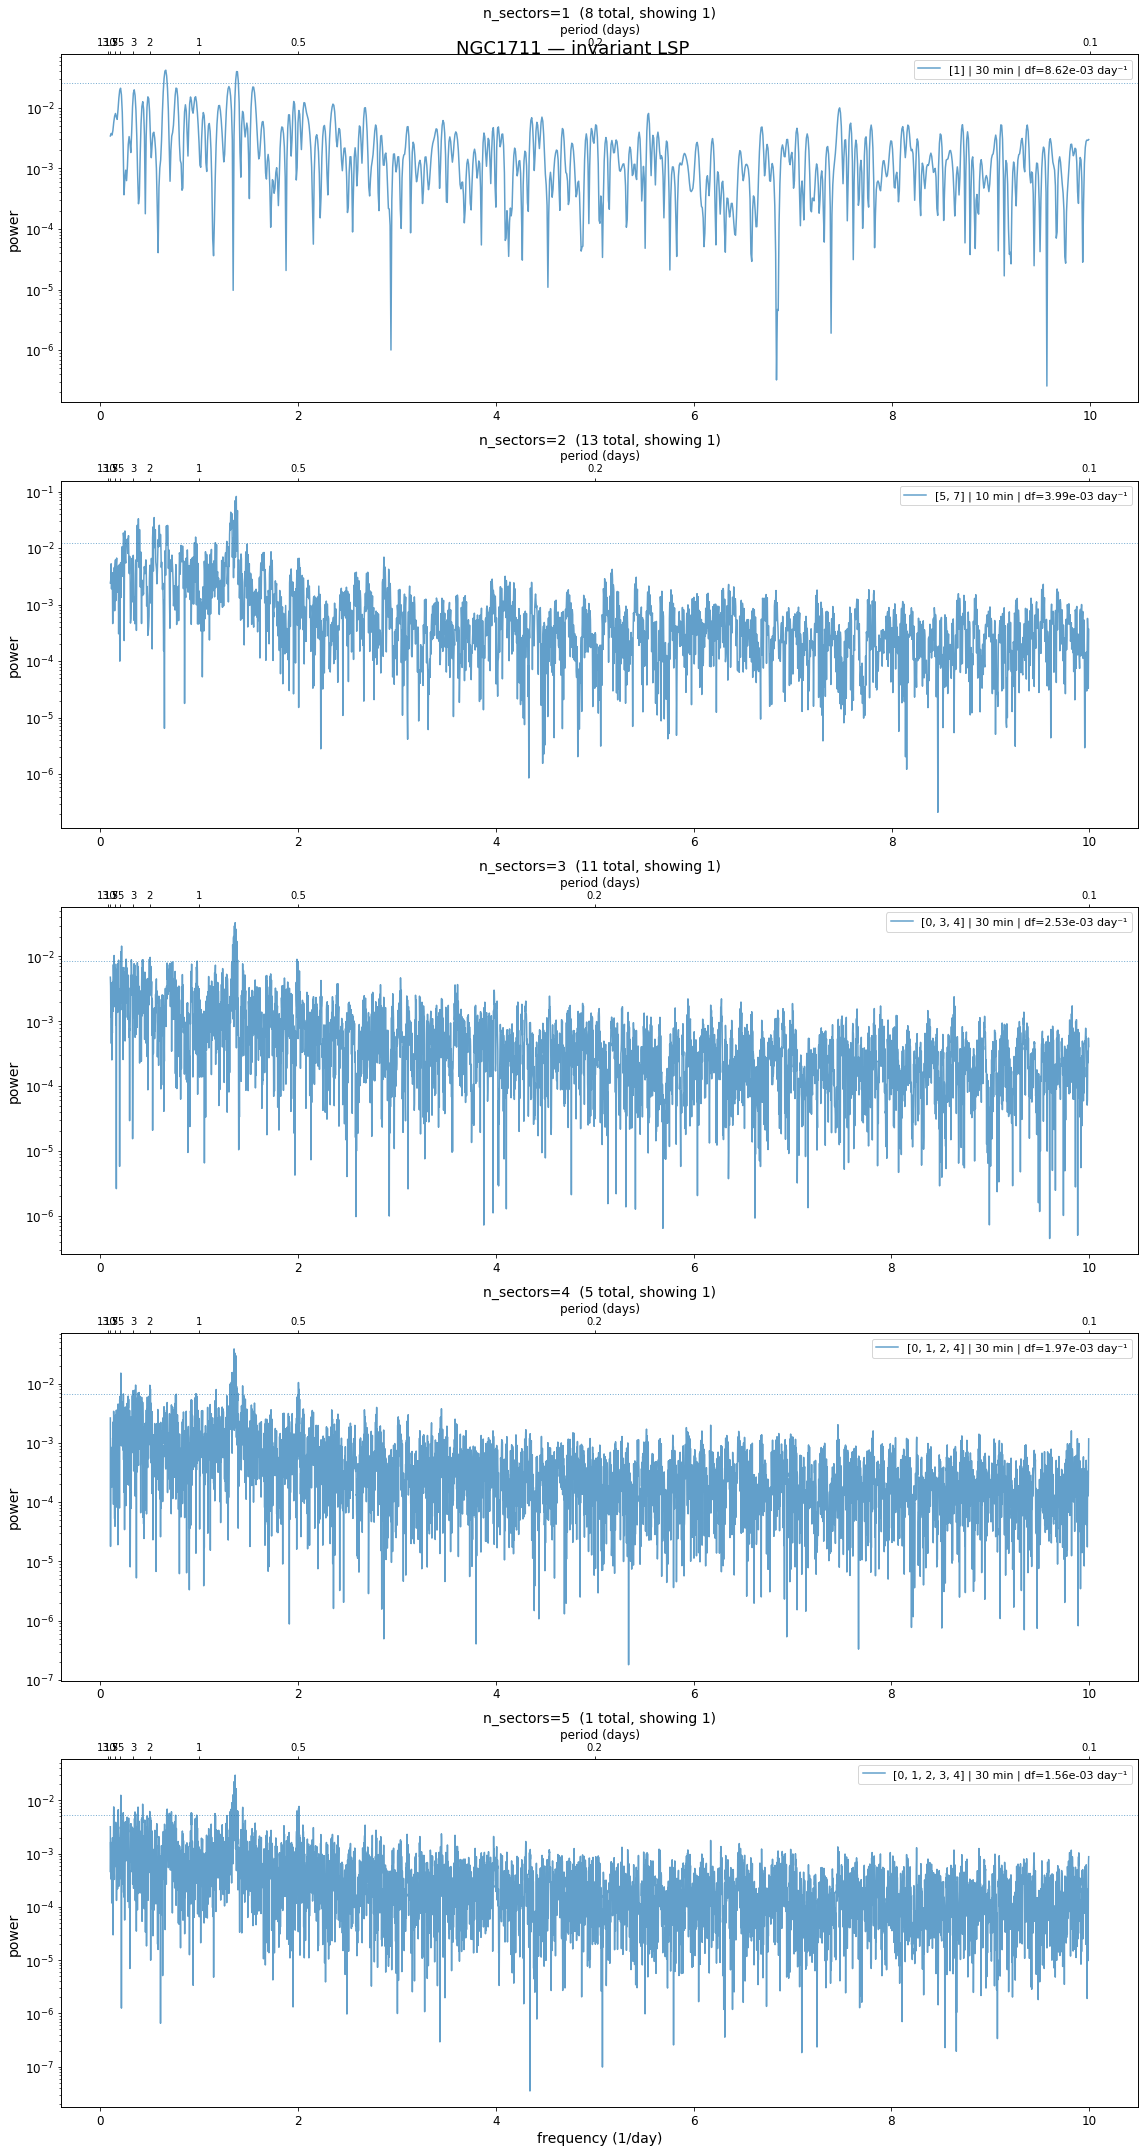

In [13]:
from vis_periodogram import plot_cluster_lsp

test_name = b'NGC 7175'
test_name = b'NGC1711'

plot_cluster_lsp(
    new_table,
    name=test_name,
    max_num_pgs=1,
    yscale='log',
)

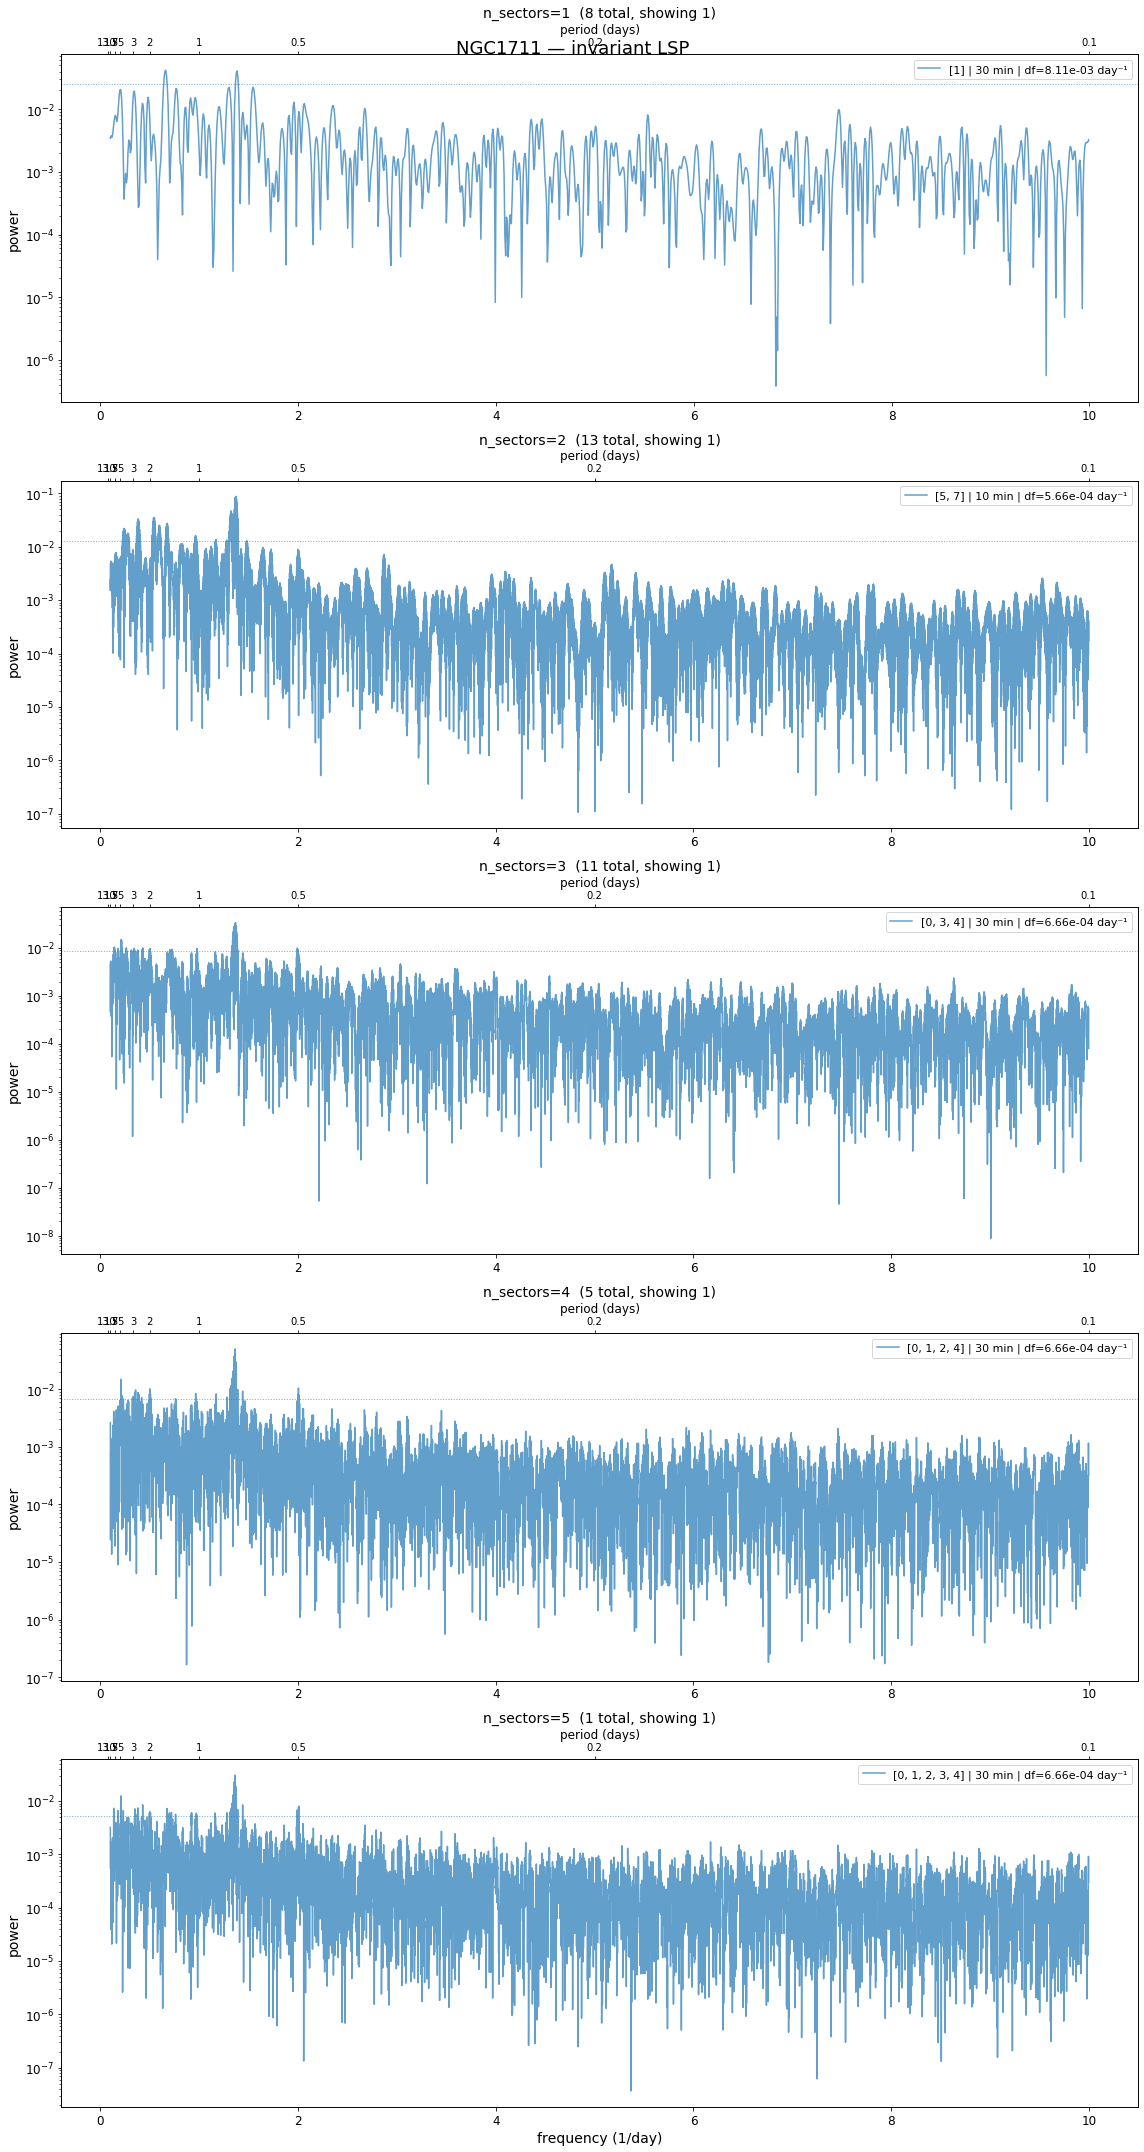

In [24]:
from vis_periodogram import plot_cluster_lsp

test_name = b'NGC 7175'
test_name = b'NGC 1711'

plot_cluster_lsp(
    new_table,
    name=test_name,
    max_num_pgs=1,
    yscale='log',
)

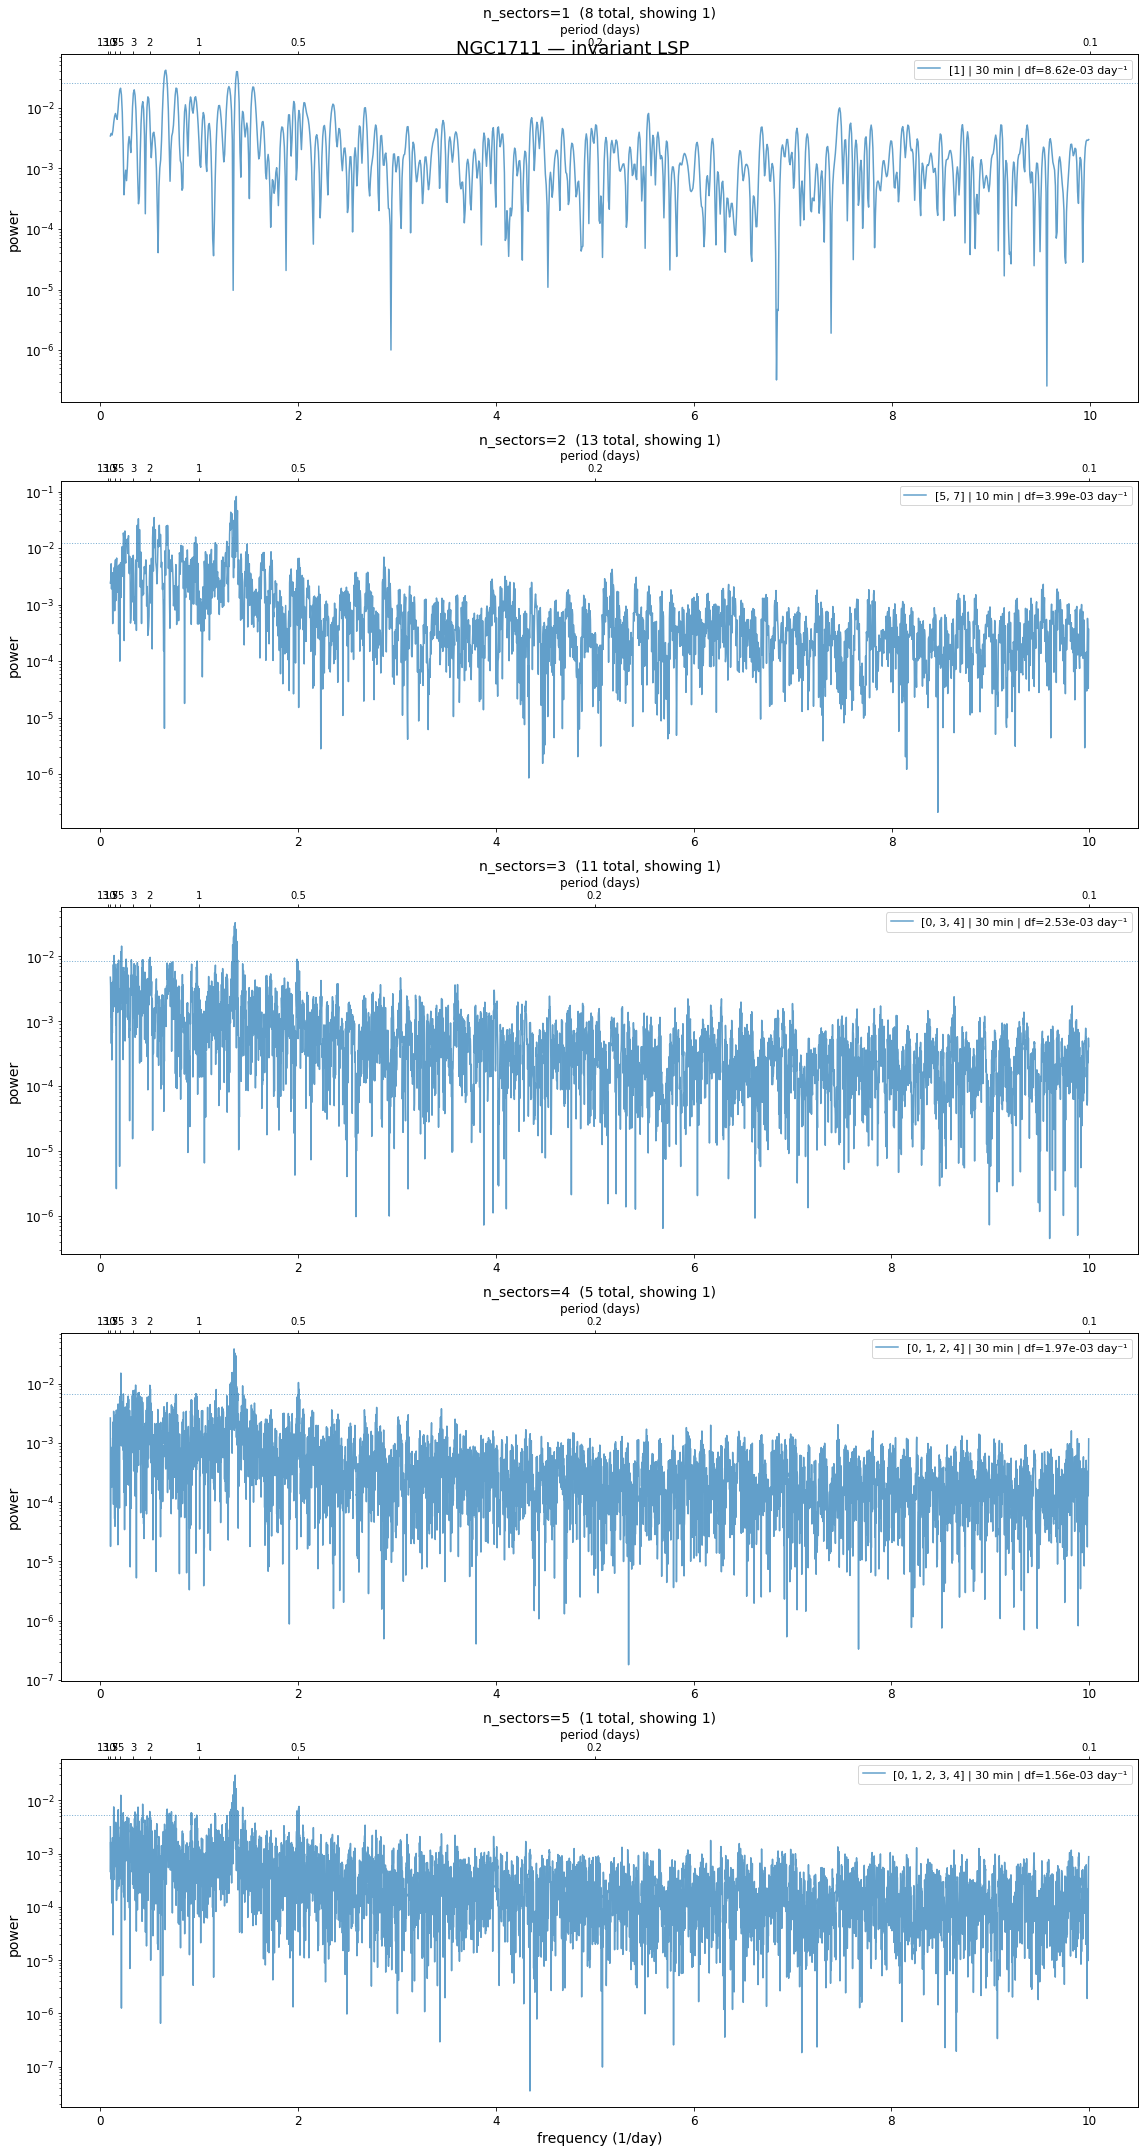

In [22]:
from vis_periodogram import plot_cluster_lsp

#test_name = b'NGC 7175'

plot_cluster_lsp(
    subset,
    name=test_name,
    max_num_pgs=1,
    yscale='log',
)

### Zoom into the rotation-period window (1 – 10 days)

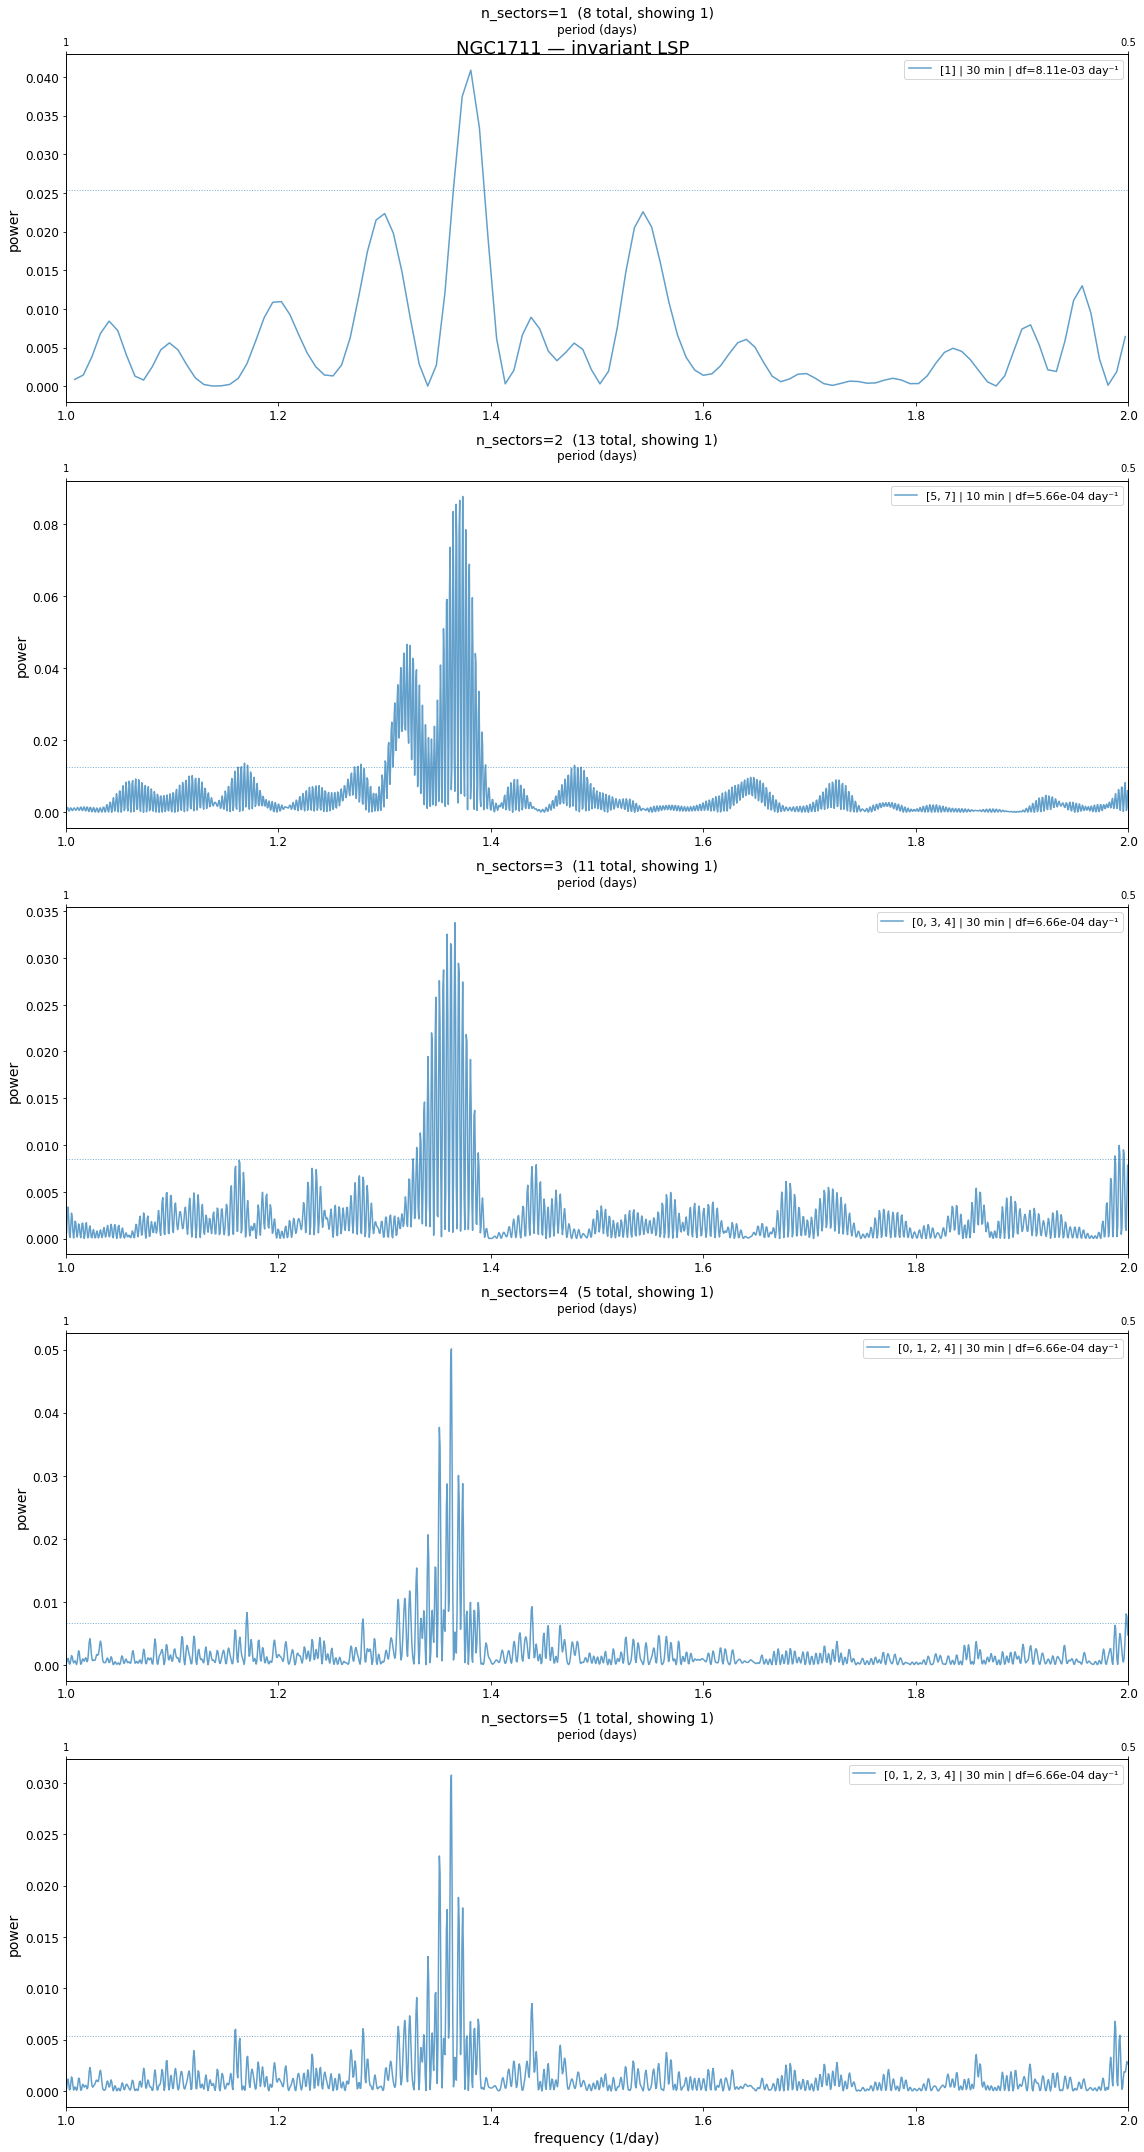

In [26]:
plot_cluster_lsp(
    subset,
    name=test_name,
    max_num_pgs=1,
    yscale='linear',
    x_lim=(1, 2),   # 1–10 day period window in frequency space
)

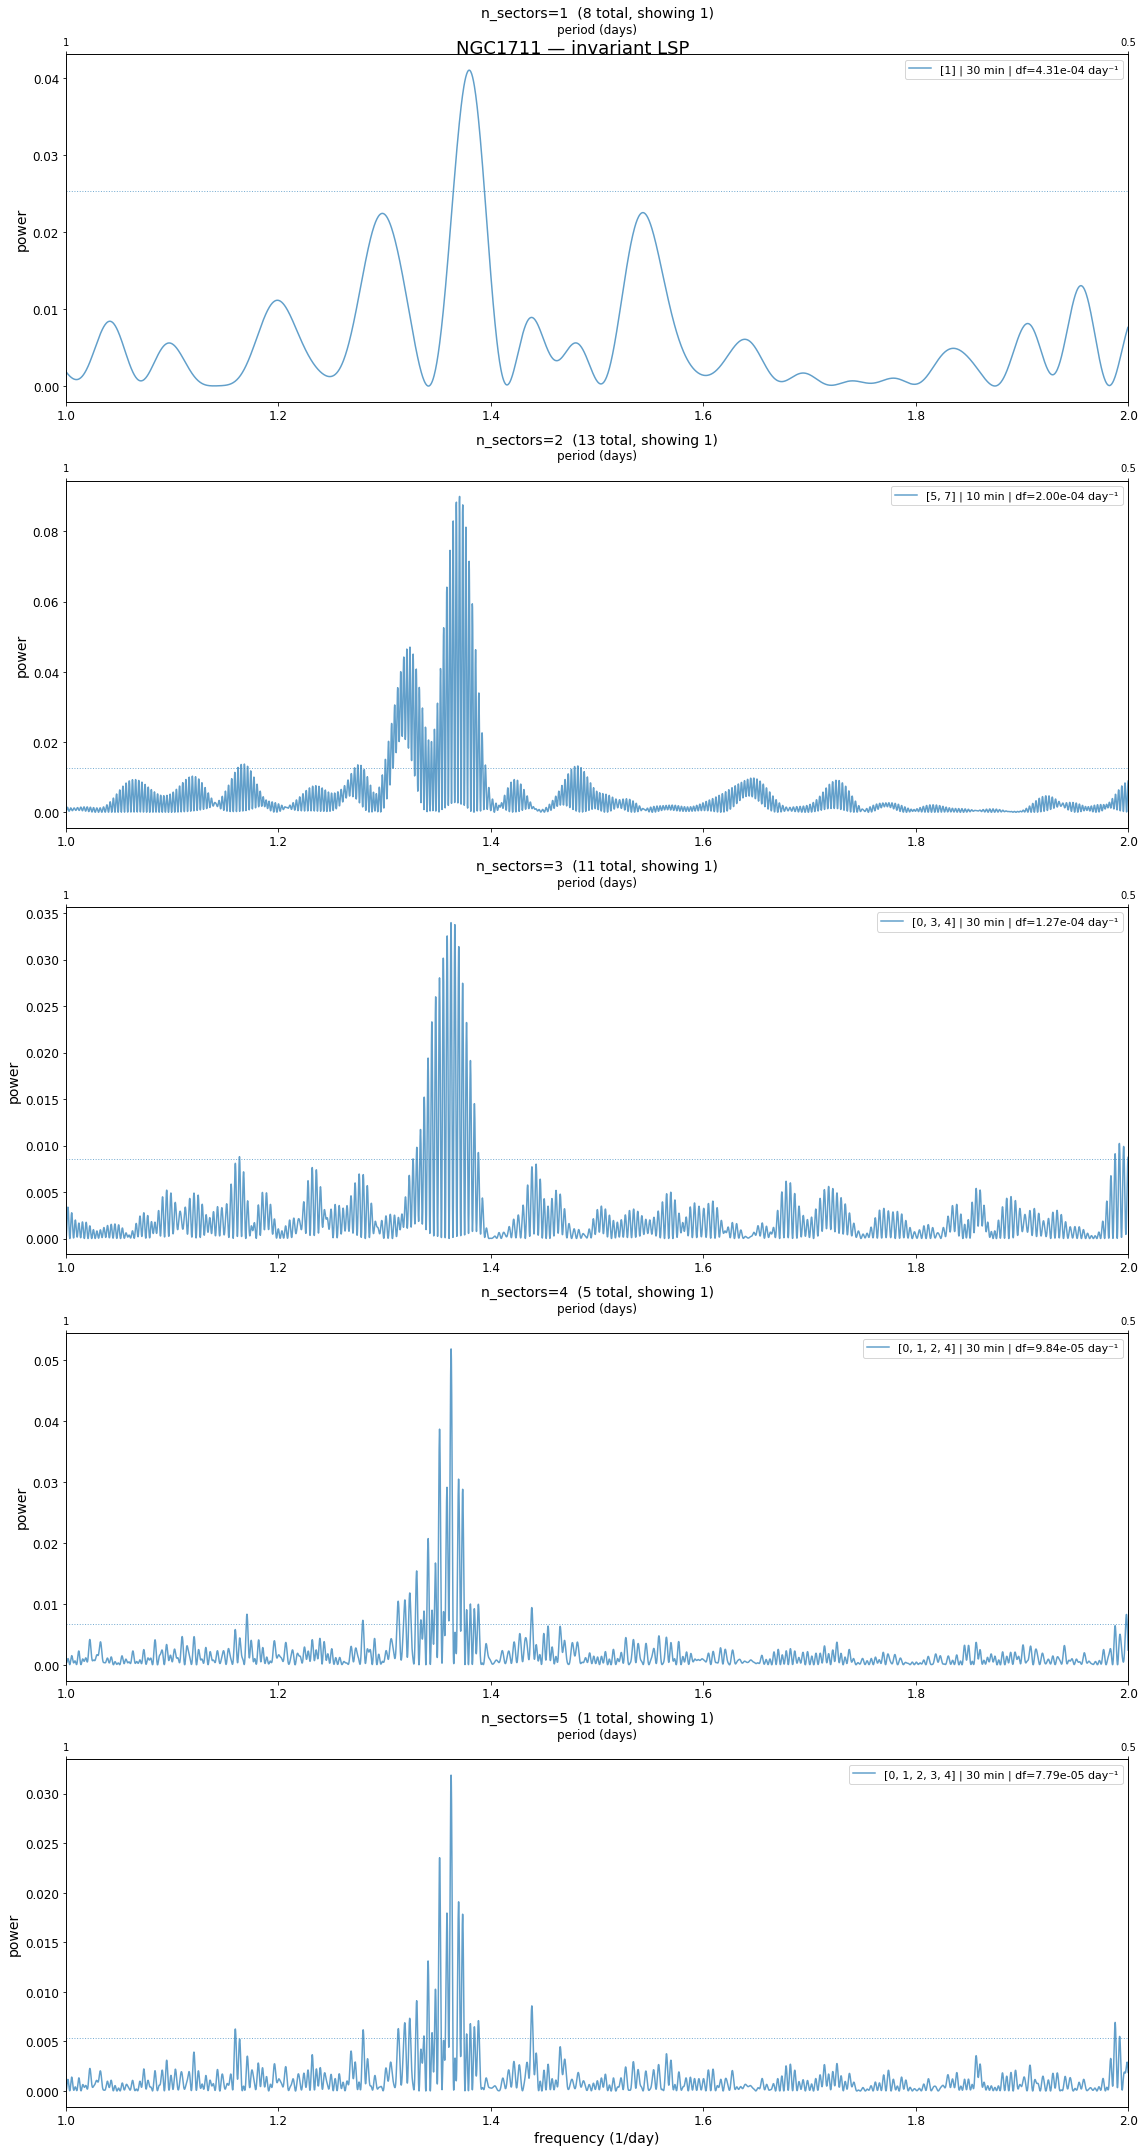

In [33]:
plot_cluster_lsp(
    subset,
    name=test_name,
    max_num_pgs=1,
    yscale='linear',
    x_lim=(1, 2),   # 1–10 day period window in frequency space
)

### Compare with the pre-computed `FullPeriodogram` for the same cluster

The old periodogram was computed with the ELK library on a fixed 1089-bin grid.
The new invariant LSP uses an oversampled adaptive grid and noise-corrected flux.

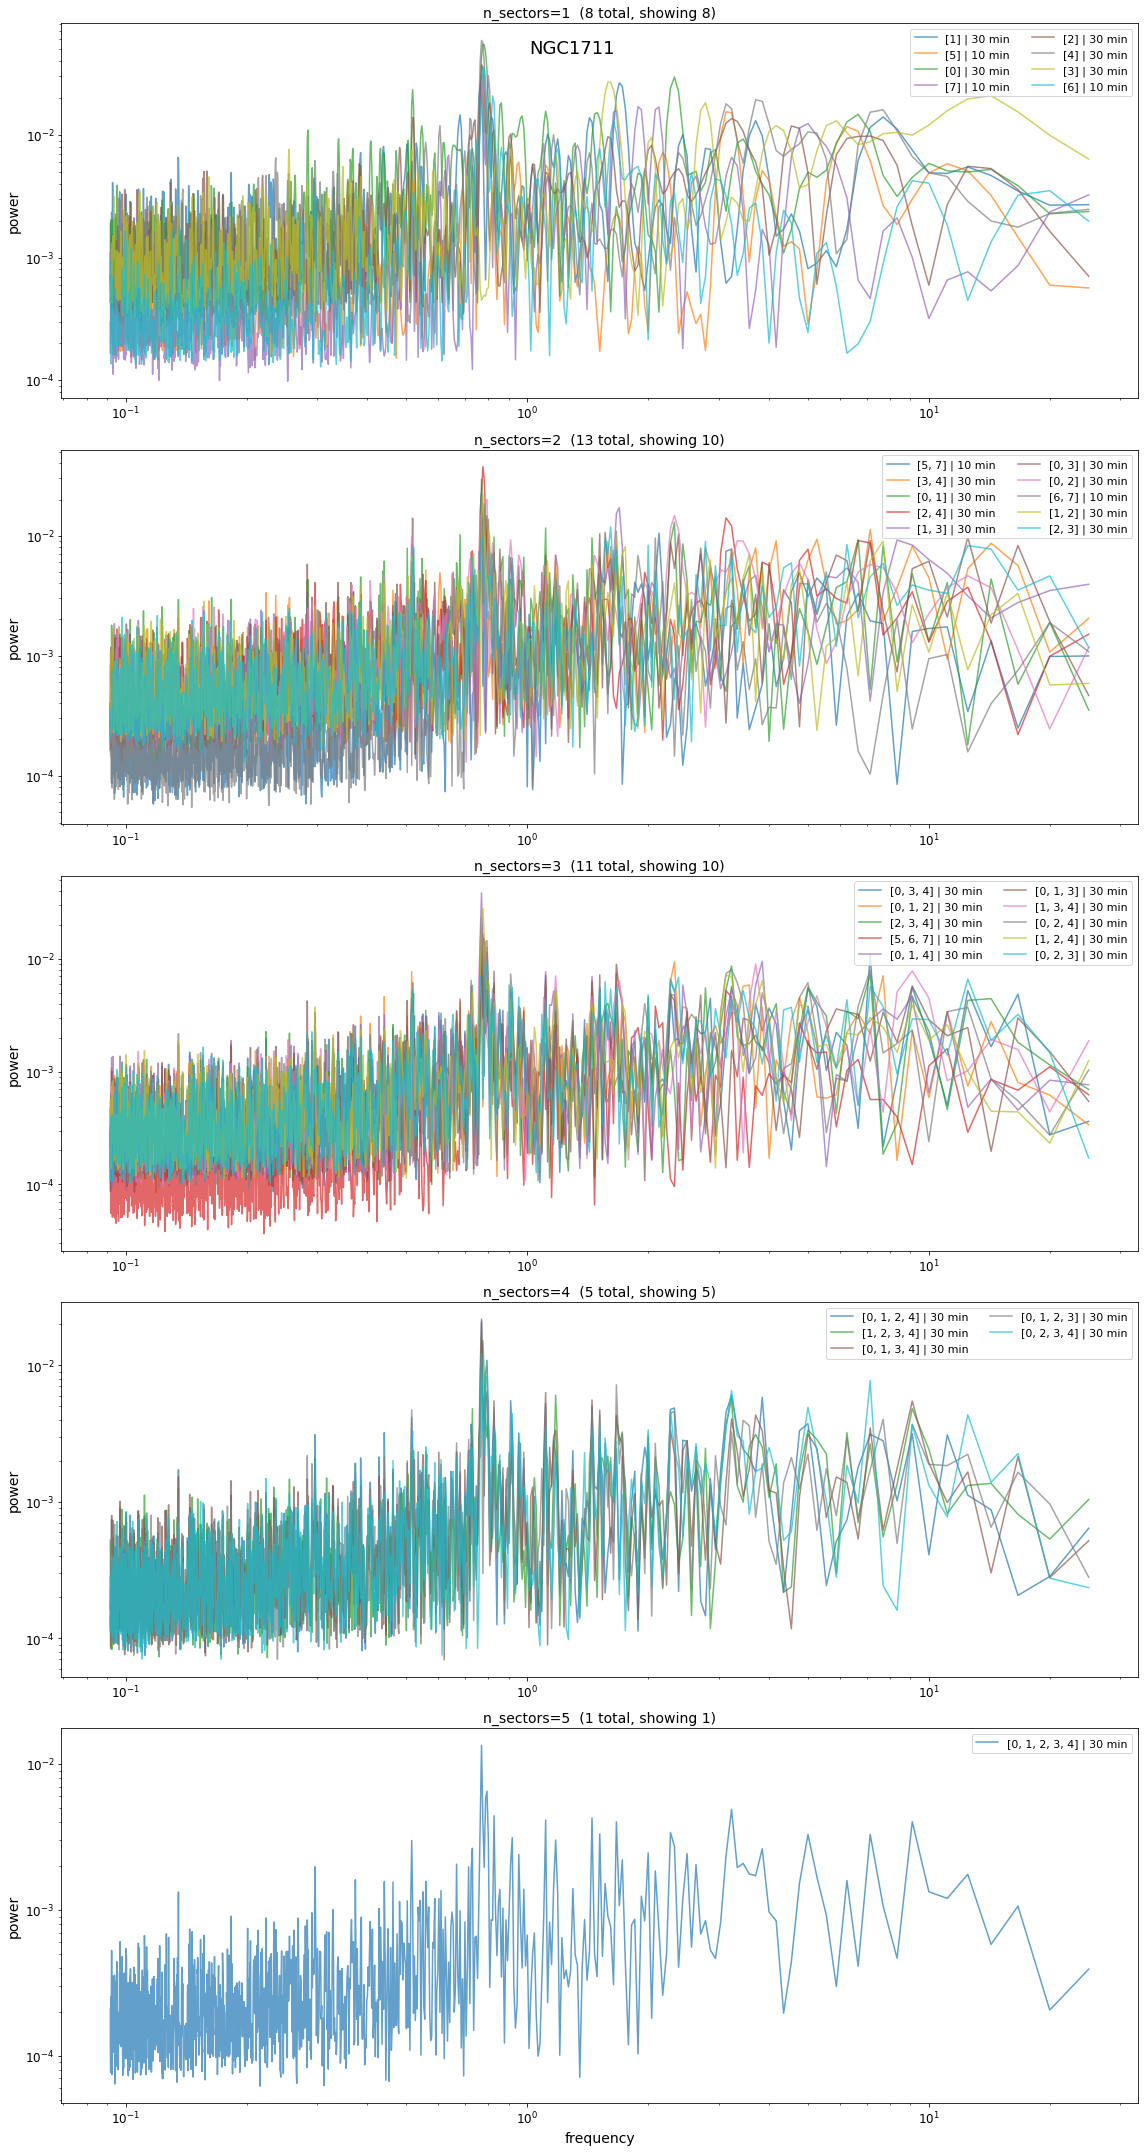

In [51]:
from vis_periodogram import plot_cluster_periodograms

# Reconstruct the frequency grid used to compute FullPeriodogram.
# The stored arrays are 1089 bins; np.arange(0.04, 11, 0.01) can give a
# different count depending on floating-point rounding across numpy versions,
# so we slice to match the actual stored length.
pg_len = len(subset['FullPeriodogram'].iloc[0])
old_freq_grid = (1.0 / np.arange(0.04, 11, 0.01))[:pg_len]

plot_cluster_periodograms(
    subset,
    name=test_name,
    frequency_bins=old_freq_grid,
    max_num_pgs=10,
    yscale='log',
    xscale='log',
)

### Old vs. new periodogram on the same axes

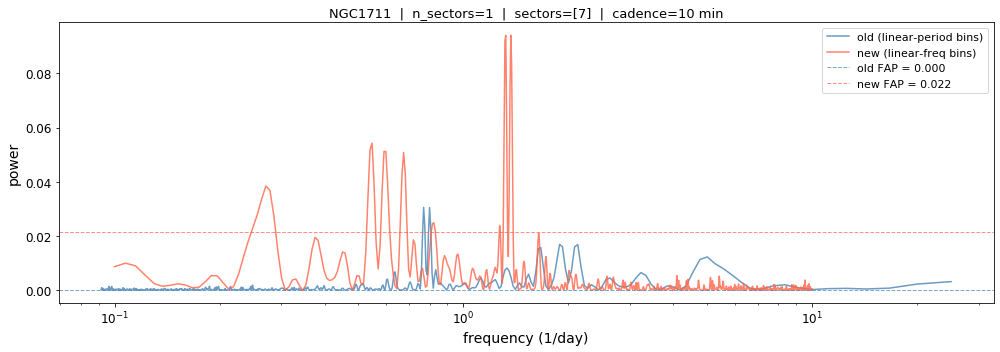

In [12]:
from vis_periodogram import plot_lsp_comparison

plot_lsp_comparison(
    subset,
    name=test_name,
    n_sectors=1,
    yscale='linear',
    xscale='log',
)

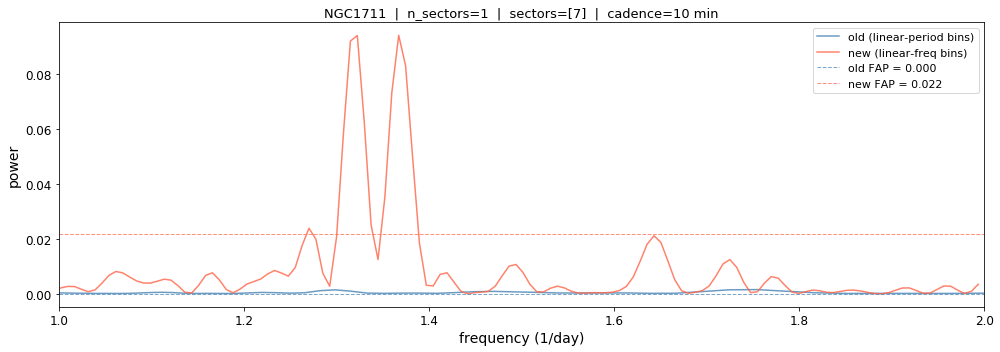

In [13]:
# Zoom into rotation-period window
plot_lsp_comparison(
    subset,
    name=test_name,
    n_sectors=1,
    x_lim=(1, 2),
    yscale='linear',
)

# Compare Old vs. New Summary Statistics

In [ ]:
Index(['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio',
       'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks',
       'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation',
       'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power',
       'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power',
       'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE',
       'FullPeriodogram', 'LSP_freq', 'LSP_power', 'LSP_max_power',
       'LSP_freq_at_max_power', 'LSP_period_at_max_power', 'LSP_FAP',
       'LSP_SumPow_10_7', 'LSP_SumPow_7_4', 'LSP_SumPow_4_1',
       'LSP_SumPow_1_p5'],
      dtype='object')


In [13]:
#plot_clusters_comparison(master_table, 1, 'SumLSP_10_7_Day_Power', comparison_column='LSP_SumPow_10_7', debug=True) 
#plot_clusters_comparison(master_table, 1, 'SumLSP_7_4_Day_Power', comparison_column='LSP_SumPow_7_4', debug=True) 
plot_clusters_comparison(master_table, 1, 'SumLSP_4_1_Day_Power', comparison_column='LSP_SumPow_4_1', debug=True) 
#plot_clusters_comparison(master_table, 1, 'SumLSP_1_p5_Day_Power', comparison_column='LSP_SumPow_1_p5', debug=True) 
#plot_clusters_comparison(master_table, 1, 'FAP', comparison_column='LSP_FAP', debug=True) 
#plot_clusters_comparison(master_table, 1, 'freq_at_max_power', comparison_column='LSP_freq_at_max_power', debug=True) 
#plot_clusters_comparison(master_table, 1, 'max_power', comparison_column='LSP_max_power', debug=True) 


NameError: name 'plot_clusters_comparison' is not defined